In [55]:
# torch
import torch
import torchvision
import torch.nn as nn
import torch.optim as optim
from torchinfo import summary
import torch.nn.functional as F
from torchvision.transforms import transforms
from torch.utils.data import Dataset, DataLoader
# utils
import os
import numpy as np
import pandas as pd
from PIL import Image
from glob import glob
from sklearn.model_selection import train_test_split, StratifiedKFold
# visualization
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay, accuracy_score, confusion_matrix, classification_report, precision_score, recall_score, f1_score, roc_auc_score
# segmentation
import cv2
from skimage.morphology import disk, binary_opening, binary_erosion


In [3]:
#check version
torch.__version__


'2.6.0+cu124'

In [4]:
# check device
device = "cuda" if torch.cuda.is_available() else "cpu"
print(device)


cpu


In [15]:
# global variables
dataset_path = "../dataset/d1"
train_path = "../dataset/d1/Training"
test_path = "../dataset/d1/Testing"
processed_train_path = "../dataset/d2/processed_train"
image_size = (224,224)
num_classes = 5
train_paths = glob(f"{processed_train_path}/*/*.jpg")
test_paths = glob(f"{test_path}/*/*.jpg")
# output save folder
graph_save_path = "../output/graph"


In [14]:
print(test_paths)


[]


In [ ]:
training_paths = [
     "../dataset/d1/Training/glioma",
     "../dataset/d1/Training/meningioma",
     "../dataset/d1/Training/notumor",
     "../dataset/d1/Training/pituitary"
]
testing_paths = [
     "../dataset/d1/Testing/glioma",
     "../dataset/d1/Testing/meningioma",
     "../dataset/d1/Testing/notumor",
     "../dataset/d1/Testing/pituitary"
]


In [60]:
# Data Analysis
def data_graph(data_paths, graph_title):
     os.makedirs(graph_save_path, exist_ok=True)
     save_path = os.path.join(graph_save_path, graph_title.replace(" ", "_") + ".png")

     data = {
        'glioma': len(os.listdir(data_paths[0])),
        'meningioma': len(os.listdir(data_paths[1])),
        'notumor': len(os.listdir(data_paths[2])),
        'pituitary': len(os.listdir(data_paths[3])),
     }
     print(data)

     typex = data.keys()
     values = data.values()

     fig = plt.figure(figsize=(5,7))

     plt.bar(typex, values, color=['red', 'blue', 'green', 'orange'])

     plt.xlabel('Data')
     plt.ylabel('No of all Brain MRI images')
     plt.title('Count of Brain Tumor Images')
     plt.savefig(save_path, dpi=300)
     plt.show()


{'glioma': 1321, 'meningioma': 1339, 'notumor': 1595, 'pituitary': 1457}


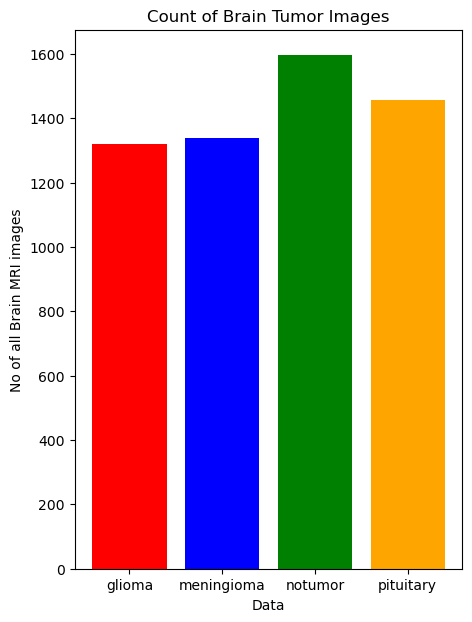

In [61]:
# training data
data_graph(training_paths, "image_distribution_for_traing_data")


{'glioma': 300, 'meningioma': 306, 'notumor': 405, 'pituitary': 300}


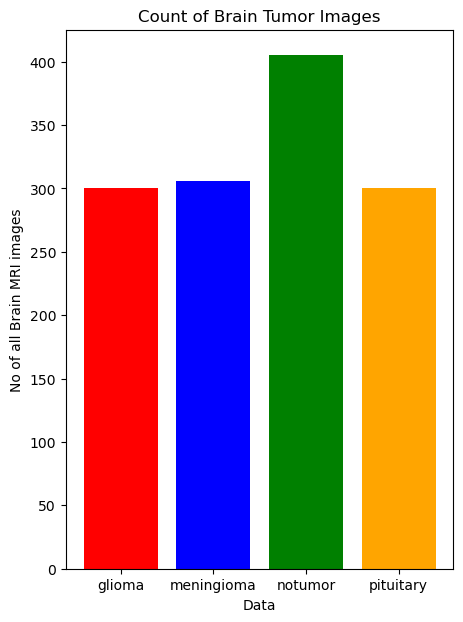

In [62]:
# testing data
data_graph(testing_paths, "image_distribution_for_testing_data")


In [63]:
def data_percentage(train_paths, test_paths):
    graph_title = "data percentage graph"
    os.makedirs(graph_save_path, exist_ok=True)
    save_path = os.path.join(graph_save_path, graph_title.replace(" ", "_") + ".png")

    train_data = {
        'glioma': len(os.listdir(train_paths[0])),
        'meningioma': len(os.listdir(train_paths[1])),
        'notumor': len(os.listdir(train_paths[2])),
        'pituitary': len(os.listdir(train_paths[3])),
    }

    test_data = {
        'glioma': len(os.listdir(test_paths[0])),
        'meningioma': len(os.listdir(test_paths[1])),
        'notumor': len(os.listdir(test_paths[2])),
        'pituitary': len(os.listdir(test_paths[3])),
    }

    total_train = sum(train_data.values())
    total_test = sum(test_data.values())

    train_percentages = {k: (v / total_train) * 100 for k, v in train_data.items()}
    test_percentages = {k: (v / total_test) * 100 for k, v in test_data.items()}

    df = pd.DataFrame({
        'Tumor Type': train_data.keys(),
        'Train Count': train_data.values(),
        'Train %': [f"{round(p)}%" for p in train_percentages.values()],
        'Test Count': test_data.values(),
        'Test %': [f"{round(p)}%" for p in test_percentages.values()]
    })

    print("\nTabular Representation of Data:\n")
    print(f'Total training data: {total_train}\tTotal Testing data: {total_test}\n')
    print(df.to_string(index=False))
    
    categories = list(train_data.keys())
    train_values = list(train_percentages.values())
    test_values = list(test_percentages.values())

    x = np.arange(len(categories))  # X positions
    width = 0.2  # Bar width

    fig, ax = plt.subplots(figsize=(7, 5))

    # Plot bars for training and testing
    ax.bar(x - width/2, train_values, width, label='Training', color='blue')
    ax.bar(x + width/2, test_values, width, label='Testing', color='green')

    # Labels and title
    ax.set_xlabel('Brain Tumor Type')
    ax.set_ylabel('Percentage of Images (%)')
    ax.set_title('Training vs Testing Dataset Distribution')
    ax.set_xticks(x)
    ax.set_xticklabels(categories)
    ax.legend()
    
    plt.savefig(save_path, dpi=300)
    plt.show()



Tabular Representation of Data:

Total training data: 5712	Total Testing data: 1311

Tumor Type  Train Count Train %  Test Count Test %
    glioma         1321     23%         300    23%
meningioma         1339     23%         306    23%
   notumor         1595     28%         405    31%
 pituitary         1457     26%         300    23%


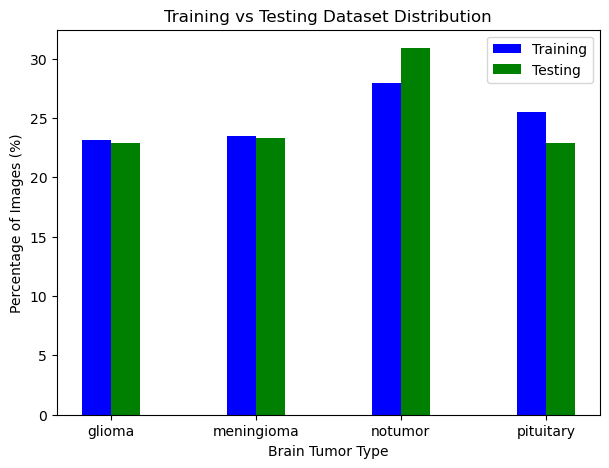

In [64]:
# data percentage
data_percentage(training_paths, testing_paths)


In [ ]:
# Skull-Stripping
def load_image(image_path): # Load the MRI image (grayscale)
    image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)  # Load in grayscale
    image = image / 255.0  # Normalize to [0,1]
    return image

# Thresholding to create a binary mask
def thresholding(image):
    t_opt = np.mean(image)  # Simple estimation for demonstration
    binary_image = (image > t_opt).astype(np.uint8)
    return binary_image

# Morphological Operations
def morphological_processing(binary_image, radius=5):
    struct_element = disk(radius)  # Disk-shaped structuring element
    cleaned = binary_opening(binary_image, struct_element)  # Remove small objects
    cleaned = binary_erosion(cleaned, struct_element)  # Further refinement
    return cleaned

# Apply Mask to Remove Skull
def apply_mask(image, mask):
    skull_stripped = image * mask  # Set non-brain areas to 0
    return skull_stripped


In [ ]:
# Load and process the image

image = load_image(image_path)

binary_mask = thresholding(image) # Thresholding

refined_mask = morphological_processing(binary_mask, radius=5) # Morphological processing

skull_stripped_image = apply_mask(image, refined_mask) # Apply mask


In [69]:
# Define paths
output_dir = "../dataset/d2/processed_train/"  # Directory to save processed images
class_names = [folder for folder in os.listdir(train_path) if os.path.isdir(os.path.join(train_path, folder))]  # Four classes

# Create output folders if they don't exist
for cls in class_names:
    os.makedirs(os.path.join(output_dir, cls), exist_ok=True)
    
print(class_names)


['glioma', 'meningioma', 'notumor', 'pituitary']


In [76]:
def skull_strip(image_path):
    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)  # Read as grayscale
    if img is None:
        print(f"Error: Unable to load image at {image_path}.")
        return None, None, None
    
    # Convert to PyTorch tensor
    img_tensor = torch.tensor(img, dtype=torch.float32)
    
    # Apply Otsu's Thresholding
    _, binary_mask = cv2.threshold(img, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

    # Morphological operations
    kernel = np.ones((5, 5), np.uint8)
    binary_mask = cv2.morphologyEx(binary_mask, cv2.MORPH_OPEN, kernel)  # Remove small objects
    binary_mask = cv2.dilate(binary_mask, kernel, iterations=2)  # Expand brain region
    
    # Apply mask
    skull_stripped = cv2.bitwise_and(img, img, mask=binary_mask)
    
    return img, binary_mask, skull_stripped


In [89]:
# Process all images in each class folder
for cls in class_names:
    class_path = os.path.join(train_path, cls)
    output_class_path = os.path.join(output_dir, cls)
    
    for img_name in os.listdir(class_path):
        img_path = os.path.join(class_path, img_name)
        
        # Apply skull stripping
        # processed_img = skull_strip(img_path)
        original, mask, processed_img = skull_strip(img_path)
        if processed_img is not None:
            save_path = os.path.join(output_class_path, img_name) # Save processed image
            cv2.imwrite(save_path, processed_img)

print("Skull stripping applied to all training images and saved in 'processed_train' folder.")


Skull stripping applied to all training images and saved in 'processed_train' folder.


In [84]:
# Display results
def test_skull_stripping(img):
    original, mask, processed_img = skull_strip(img)

    graph_title = "skull_strip_test_img"
    os.makedirs(graph_save_path, exist_ok=True)

    existing_files = [f for f in os.listdir(graph_save_path) if f.startswith(graph_title) and f.endswith(".png")]
    next_number = len(existing_files) + 1
    save_path = os.path.join(graph_save_path, f"{graph_title}_{next_number}.png")

    if original is not None:
        fig, axes = plt.subplots(1, 3, figsize=(12, 4))

        axes[0].imshow(original, cmap='gray')
        axes[0].set_title("Original Image")
        axes[0].axis("off")

        axes[1].imshow(mask, cmap='gray')
        axes[1].set_title("Binary Mask")
        axes[1].axis("off")

        axes[2].imshow(processed_img, cmap='gray')
        axes[2].set_title("Skull-Stripped Image")
        axes[2].axis("off")

        plt.tight_layout()
        plt.savefig(save_path, dpi=300)
        plt.show()


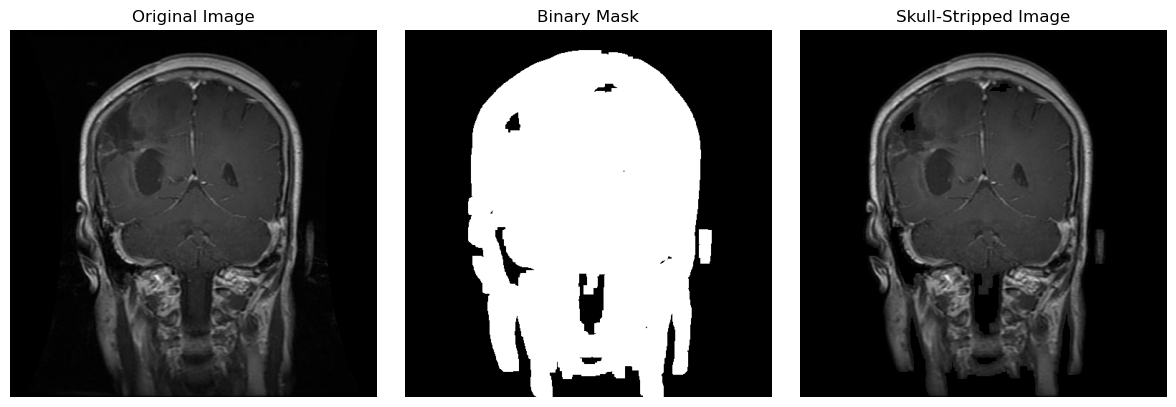

In [85]:
skull_strip_test_img_1 = "../dataset/d1/Training/glioma/Tr-gl_0010.jpg"
test_skull_stripping(skull_strip_test_img_1)


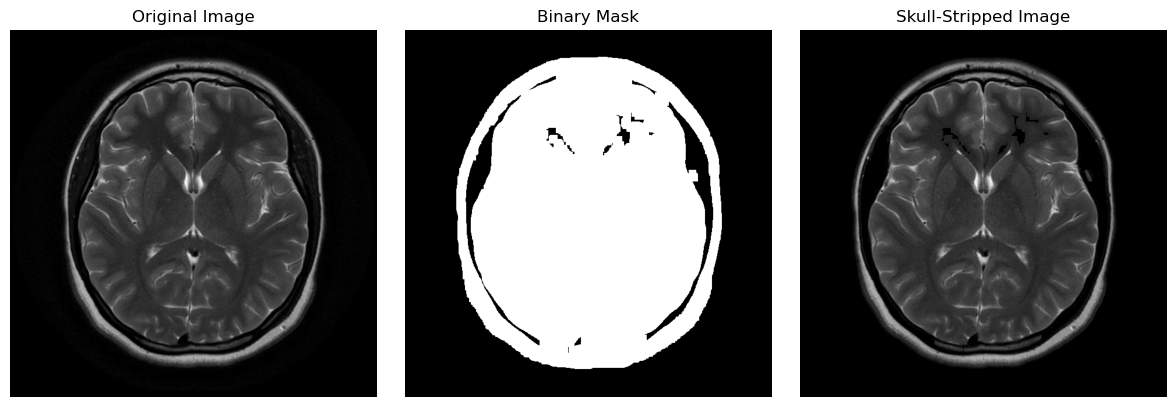

In [87]:
skull_strip_test_img_2 = "../dataset/d1/Training/notumor/Tr-no_0011.jpg"
test_skull_stripping(skull_strip_test_img_2)


In [7]:
# data augmentation
train_transform = transforms.Compose([
    transforms.RandomRotation(degrees=(-30, 30)),  # Rotation from -30° to 30°
    transforms.RandomAffine(degrees=0, translate=(10/100, 10/100)),  # Translation in X and Y
    transforms.RandomHorizontalFlip(p=0.5),  # Random reflection along X-axis
    transforms.RandomVerticalFlip(p=0.5),  # Random reflection along Y-axis
    transforms.RandomResizedCrop(size=(224, 224), scale=(0.5, 4.0)),  # Scaling from 0.5x to 4x
    transforms.RandomAffine(degrees=0, shear=(0, 30)),  # Shearing from 0° to 30°
    transforms.Resize(image_size),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

test_transform = transforms.Compose([
    transforms.Resize(image_size),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])


In [8]:
# custom dataset class
class dataset(Dataset):
    def __init__(self,paths,transform=None):
        self.paths = paths
        self.transform = transform
        self.labels = [self.get_label(path) for path in self.paths]
        self.labels_to_index = {label:index for index,label in enumerate(list(set(self.labels)))}
    
    def __getitem__(self,index):
        img_path = self.paths[index]
        img = Image.open(img_path).convert('RGB') 
        label = self.labels[index]
        label_index = self.labels_to_index[label]
        
        if self.transform:
            img = self.transform(img)
        
        return img, label_index,label
    
    
    def __len__(self):
        return len(self.paths)
    
    
    def get_label(self, path):
        return os.path.basename(os.path.dirname(path))


In [9]:
train_dataset = dataset(train_paths, transform=train_transform)
test_dataset = dataset(test_paths, transform=test_transform)


In [10]:
val_dataset, test_dataset = train_test_split(test_dataset,test_size=0.5, random_state=ord("H"))


In [11]:
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)


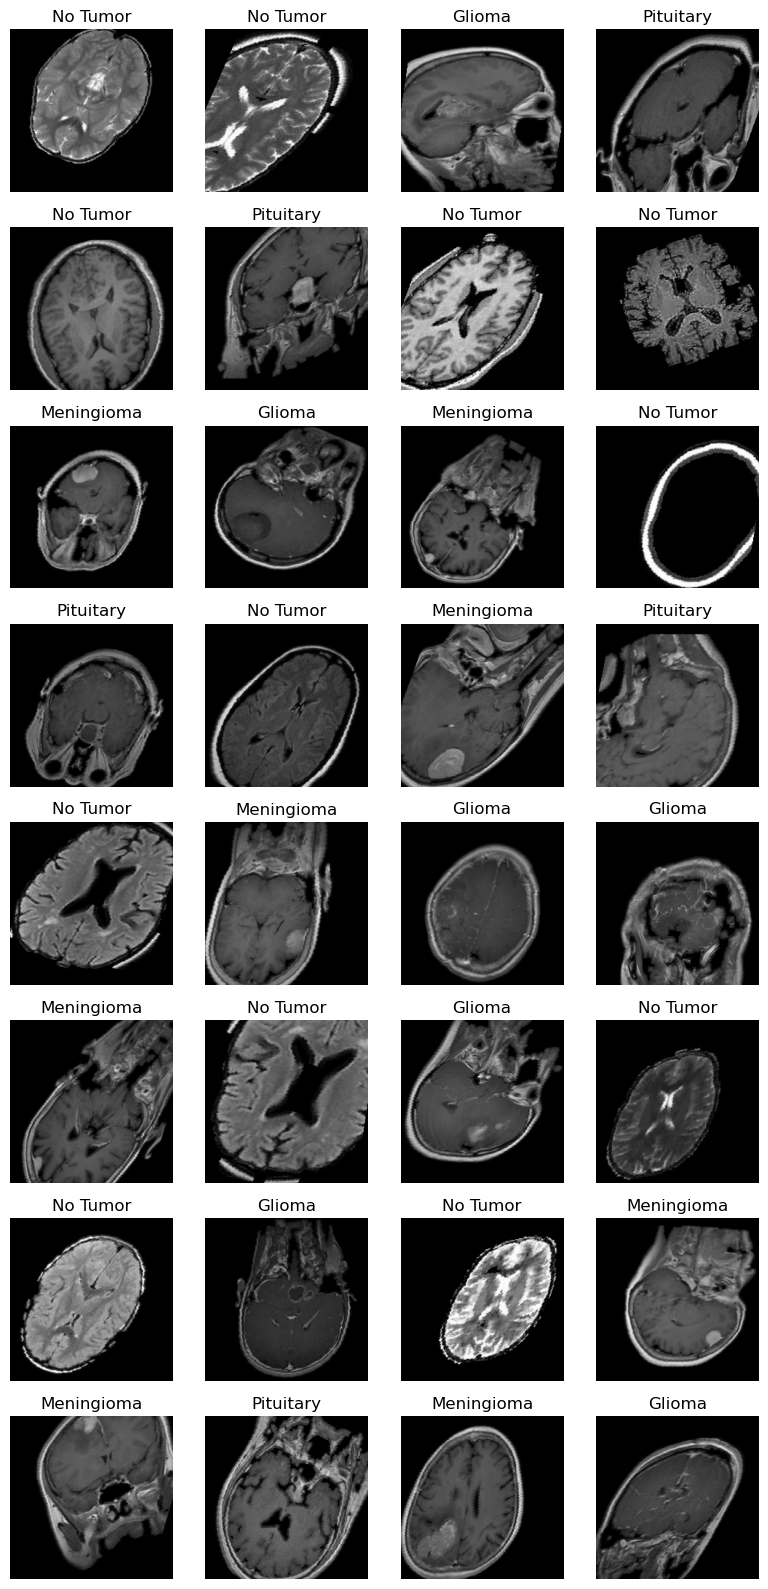

In [16]:
# display sample images with classes
train_iter = iter(train_loader)
images, labels_indices, labels = next(train_iter)

def imshow(input_images, labels_indices,labels):

    graph_title = "all_classes_img"
    os.makedirs(graph_save_path, exist_ok=True)

    existing_files = [f for f in os.listdir(graph_save_path) if f.startswith(graph_title) and f.endswith(".png")]
    next_number = len(existing_files) + 1
    save_path = os.path.join(graph_save_path, f"{graph_title}_{next_number}.png")

    label_dict = {"notumor":"No Tumor", "glioma":"Glioma", "meningioma":"Meningioma","pituitary":"Pituitary"}
    input_images=input_images.numpy().transpose((0,2, 3, 1))
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    input_images = std * input_images + mean
    input_images = np.clip(input_images, 0, 1)
    fig, axes = plt.subplots(8, 4, figsize=(8, 16))
    for i, ax in enumerate(axes.flat):
        ax.imshow(input_images[i])
        ax.axis('off')
        ax.set_title(label_dict[labels[i]], fontsize=12)
    plt.tight_layout()
    plt.savefig(save_path, dpi=300)
    plt.show()


imshow(images, labels_indices,labels)


In [17]:
class CNN_Model(nn.Module):
    def __init__(self, num_classes):  
        super(CNN_Model, self).__init__()

        self.conv1 = nn.Conv2d(in_channels=3, out_channels=32, kernel_size=5, stride=2)
        self.bn1 = nn.BatchNorm2d(32)

        self.conv2_1 = nn.Conv2d(32, 48, kernel_size=3, stride=2)
        self.bn2_1 = nn.BatchNorm2d(48)
        self.conv2_2 = nn.Conv2d(48, 48, kernel_size=3, stride=1)
        self.bn2_2 = nn.BatchNorm2d(48)
        self.conv2_3 = nn.Conv2d(48, 48, kernel_size=1, stride=1)
        self.bn2_3 = nn.BatchNorm2d(48)
        self.pool2 = nn.AvgPool2d(kernel_size=2, stride=2)

        self.conv3_1 = nn.Conv2d(48, 64, kernel_size=3, stride=1)
        self.bn3_1 = nn.BatchNorm2d(64)
        self.conv3_2 = nn.Conv2d(64, 64, kernel_size=3, stride=1)
        self.bn3_2 = nn.BatchNorm2d(64)
        self.conv3_3 = nn.Conv2d(64, 64, kernel_size=1, stride=1)
        self.bn3_3 = nn.BatchNorm2d(64)
        self.pool3 = nn.AvgPool2d(kernel_size=2, stride=2)

        self.conv4_1 = nn.Conv2d(64, 128, kernel_size=3)
        self.bn4_1 = nn.BatchNorm2d(128)
        self.conv4_2 = nn.Conv2d(128, 128, kernel_size=3)
        self.bn4_2 = nn.BatchNorm2d(128)
        self.conv4_3 = nn.Conv2d(128, 128, kernel_size=1)
        self.bn4_3 = nn.BatchNorm2d(128)
        self.pool4 = nn.AvgPool2d(kernel_size=2, stride=2)

        self.gap = nn.AdaptiveAvgPool2d((1, 1))

        self.fc = nn.Linear(128, num_classes)
        self.softmax = nn.Softmax(dim=1)

    def forward(self, x):
        x = F.softplus(self.bn1(self.conv1(x)))

        x = F.softplus(self.bn2_1(self.conv2_1(x)))
        x = F.softplus(self.bn2_2(self.conv2_2(x)))
        x = F.softplus(self.bn2_3(self.conv2_3(x)))
        x = self.pool2(x)

        x = F.softplus(self.bn3_1(self.conv3_1(x)))
        x = F.softplus(self.bn3_2(self.conv3_2(x)))
        x = F.softplus(self.bn3_3(self.conv3_3(x)))
        x = self.pool3(x)

        x = F.softplus(self.bn4_1(self.conv4_1(x)))
        x = F.softplus(self.bn4_2(self.conv4_2(x)))
        x = F.softplus(self.bn4_3(self.conv4_3(x)))
        x = self.pool4(x)

        x = self.gap(x)

        x = torch.flatten(x, 1)

        x = self.fc(x)
        x = self.softmax(x) 

        return x 



In [18]:
model = CNN_Model(num_classes=4)


In [19]:
print("\n\nBatch 32:\n")
summary(model, input_size=(32, 3, 224, 224))




Batch 32:



Layer (type:depth-idx)                   Output Shape              Param #
CNN_Model                                [32, 4]                   --
├─Conv2d: 1-1                            [32, 32, 110, 110]        2,432
├─BatchNorm2d: 1-2                       [32, 32, 110, 110]        64
├─Conv2d: 1-3                            [32, 48, 54, 54]          13,872
├─BatchNorm2d: 1-4                       [32, 48, 54, 54]          96
├─Conv2d: 1-5                            [32, 48, 52, 52]          20,784
├─BatchNorm2d: 1-6                       [32, 48, 52, 52]          96
├─Conv2d: 1-7                            [32, 48, 52, 52]          2,352
├─BatchNorm2d: 1-8                       [32, 48, 52, 52]          96
├─AvgPool2d: 1-9                         [32, 48, 26, 26]          --
├─Conv2d: 1-10                           [32, 64, 24, 24]          27,712
├─BatchNorm2d: 1-11                      [32, 64, 24, 24]          128
├─Conv2d: 1-12                           [32, 64, 22, 22]         

In [20]:
summary_data = summary(model, input_size=(32, 3, 224, 224), verbose=0)

print(f"{'Block':<7} {'Layers and Specifications':<45} {'Size of the Activations':<25} {'Parameters':>10}")
print("-" * 95)

block_counter = 0
block_num = "-"

for layer in summary_data.summary_list:
    layer_type = layer.class_name
    output_shape = layer.output_size
    params = layer.num_params

    if "Conv2d" in layer_type and layer.input_size != layer.output_size:
        block_counter += 1
        block_num = f"{block_counter}" if block_counter <= 4 else "-"

    if "Conv2d" in layer_type:
        ks = layer.kernel_size
        ksize = f"{ks[0]}×{ks[1]}" if isinstance(ks, (tuple, list)) else f"{ks}×{ks}"
        out_channels = output_shape[1] if isinstance(output_shape, (tuple, list)) else 'N/A'
        desc = f"{ksize} Convolution with {out_channels} filters"
    elif "BatchNorm" in layer_type:
        desc = "Batch Norm"
    elif "AvgPool" in layer_type:
        ks = layer.kernel_size
        ksize = f"{ks[0]}×{ks[1]}" if isinstance(ks, (tuple, list)) else f"{ks}×{ks}"
        desc = f"{ksize} Average Pooling"
    elif "AdaptiveAvgPool" in layer_type:
        desc = "Global Average Pooling"
    elif "Linear" in layer_type:
        desc = "Fully Connected Layer"
    else:
        desc = layer_type

    if isinstance(output_shape, (tuple, list)) and len(output_shape) == 4:
        formatted_shape = f"{output_shape[2]} × {output_shape[3]} × {output_shape[1]}"
    else:
        formatted_shape = str(output_shape)

    print(f"{block_num:<7} {desc:<45} {formatted_shape:<25} {params:>10,}")

print("-" * 95)
print(f"{'':<7} {'Trainable parameters':<45} {'':<25} {summary_data.trainable_params:>10,}")
print(f"{'':<7} {'Non-trainable parameters':<45} {'':<25} {summary_data.total_params - summary_data.trainable_params:>10,}")
print(f"{'':<7} {'Total parameters':<45} {'':<25} {summary_data.total_params:>10,}")


Block   Layers and Specifications                     Size of the Activations   Parameters
-----------------------------------------------------------------------------------------------
-       CNN_Model                                     [32, 4]                      348,212
1       5×5 Convolution with 32 filters               110 × 110 × 32                 2,432
1       Batch Norm                                    110 × 110 × 32                    64
2       3×3 Convolution with 48 filters               54 × 54 × 48                  13,872
2       Batch Norm                                    54 × 54 × 48                      96
3       3×3 Convolution with 48 filters               52 × 52 × 48                  20,784
3       Batch Norm                                    52 × 52 × 48                      96
3       1×1 Convolution with 48 filters               52 × 52 × 48                   2,352
3       Batch Norm                                    52 × 52 × 48                   

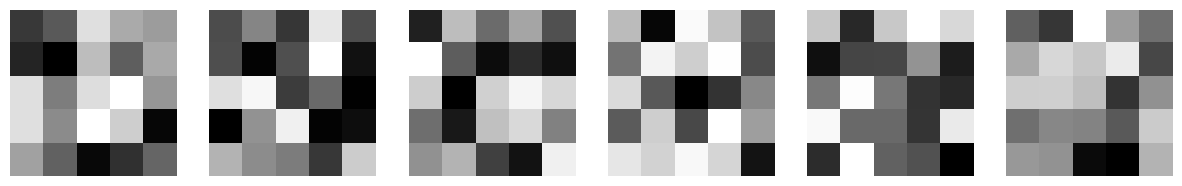

In [22]:
# Get the first convolutional layer
first_layer = model.conv1.weight.data.cpu()

# Plot the first 6 filters
fig, axes = plt.subplots(1, 6, figsize=(15, 5))
for i in range(6):
    axes[i].imshow(first_layer[i, 0].numpy(), cmap='gray')
    axes[i].axis('off')
plt.show()


In [23]:
model = CNN_Model(num_classes=4).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(),lr=0.0002)


In [24]:
def train_epoch():
    model.train()
    total_loss = 0.0 
    total_correct = 0
    total_predictions = 0
    
    for batch_number, (images, labels_indices, labels) in enumerate(train_loader):
        images, labels_indices = images.to(device), labels_indices.to(device)
        
        optimizer.zero_grad()
        
        outputs = model(images)
        loss = criterion(outputs, labels_indices)
        total_loss += loss.item()
        
        # Calculate accuracy
        _, predicted = torch.max(outputs, 1)
        total_predictions += labels_indices.size(0)
        total_correct += (predicted == labels_indices).sum().item()
        
        loss.backward()
        optimizer.step()
        
        if (batch_number and batch_number % 150 == 0):
            c_loss = total_loss / (batch_number + 1)
            accuracy = total_correct / total_predictions
            print(f"Batch {batch_number}/{len(train_loader)}, Loss: {c_loss:0.4f}, Accuracy: {accuracy * 100:.2f}%")
    
    avg_loss = total_loss / len(train_loader)
    avg_accuracy = total_correct / total_predictions
    
    return avg_loss, avg_accuracy


In [25]:
def eval_model():
    model.eval()
    total_loss = 0.0 
    total_correct = 0
    total_predictions = 0
    
    with torch.no_grad():
        for batch_number, (images, labels_indices, labels) in enumerate(val_loader):
            images, labels_indices = images.to(device), labels_indices.to(device)
            
            outputs = model(images)
            loss = criterion(outputs, labels_indices)
            total_loss += loss.item()
            
            # Calculate accuracy
            _, predicted = torch.max(outputs, 1)
            total_predictions += labels_indices.size(0)
            total_correct += (predicted == labels_indices).sum().item()
            
    avg_loss = total_loss / len(val_loader)
    avg_accuracy = total_correct / total_predictions
    
    return avg_loss, avg_accuracy


In [26]:
train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []


In [28]:
best_score = float("inf")
n_epochs = 40
tolerance = 0

model_output_path = "../output/models"
os.makedirs(model_output_path, exist_ok=True)

for epoch in range(n_epochs):
    print(f"Epoch {epoch},   ", end="")
    avg_train_loss, train_accuracy = train_epoch()
    avg_eval_loss, eval_accuracy = eval_model()
    
    if avg_eval_loss < best_score:
        best_score = avg_eval_loss
        torch.save(model.state_dict(), os.path.join(model_output_path, f"model_{epoch+1}"))
        tolerance = 0
    else:
        tolerance += 1
        if tolerance >= 8:
            break
            
    train_losses.append(avg_train_loss)
    val_losses.append(avg_eval_loss)
    train_accuracies.append(train_accuracy)
    val_accuracies.append(eval_accuracy)
    
    print(f"Train Loss: {avg_train_loss:.4f}, Train Accuracy: {train_accuracy * 100:.2f}%")
    print(f"Eval Loss: {avg_eval_loss:.4f}, Eval Accuracy: {eval_accuracy * 100:.2f}%")
    print("#" * 70)


Epoch 0,   Batch 150/179, Loss: 1.1695, Accuracy: 59.29%
Train Loss: 1.1584, Train Accuracy: 60.59%
Eval Loss: 1.1255, Eval Accuracy: 61.83%
######################################################################
Epoch 1,   Batch 150/179, Loss: 1.0715, Accuracy: 69.74%
Train Loss: 1.0688, Train Accuracy: 69.92%
Eval Loss: 1.2364, Eval Accuracy: 49.92%
######################################################################
Epoch 2,   Batch 150/179, Loss: 1.0323, Accuracy: 73.43%
Train Loss: 1.0312, Train Accuracy: 73.55%
Eval Loss: 1.2664, Eval Accuracy: 45.04%
######################################################################
Epoch 3,   Batch 150/179, Loss: 1.0048, Accuracy: 75.89%
Train Loss: 1.0064, Train Accuracy: 75.67%
Eval Loss: 1.1797, Eval Accuracy: 53.74%
######################################################################
Epoch 4,   Batch 150/179, Loss: 1.0021, Accuracy: 75.64%
Train Loss: 1.0004, Train Accuracy: 75.88%
Eval Loss: 1.1159, Eval Accuracy: 60.15%
###########

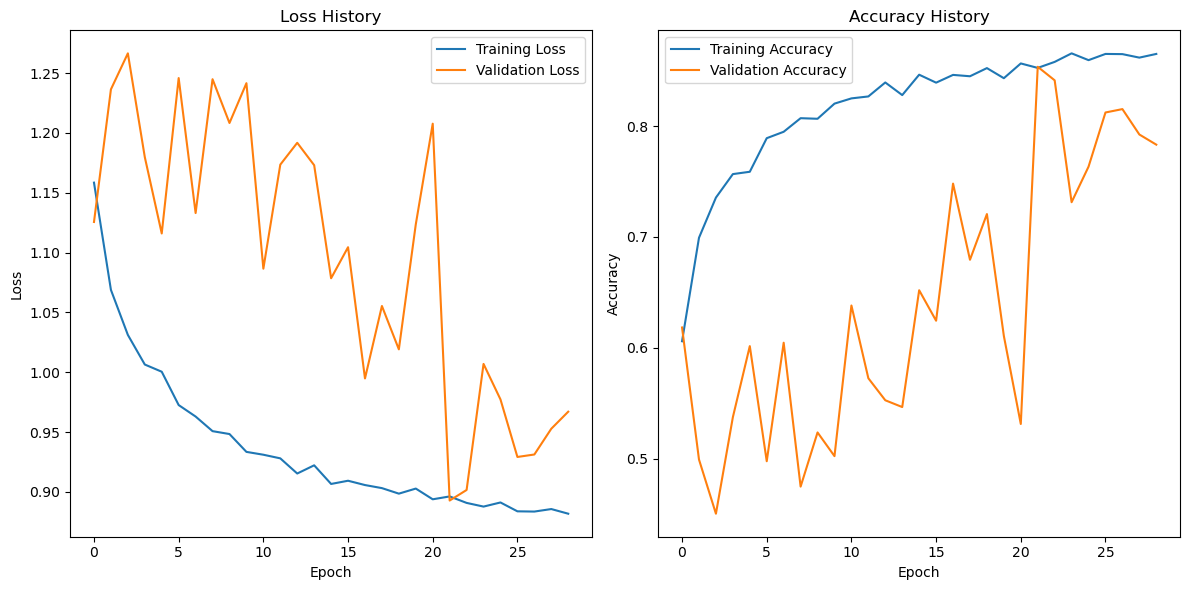

In [29]:
# Visualize training history
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Training Loss')
plt.plot(val_losses, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('Loss History')

plt.subplot(1, 2, 2)
plt.plot(train_accuracies, label='Training Accuracy')
plt.plot(val_accuracies, label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Accuracy History')

plt.tight_layout()
plt.show()


In [31]:
models = glob("../output/models/*")
model_num = [int(i.split("_")[-1]) for i in models if i.split("_")[-1].isdigit()]
best_model_path = "../output/models/model_" + str(sorted(model_num)[-1])
best_model_path


'../output/models/model_22'

In [33]:
best_model = CNN_Model(num_classes=4).to(device)

best_model.load_state_dict(torch.load(best_model_path, map_location=device))


<All keys matched successfully>

In [34]:
def predict(
    model:nn.Module, 
    sample_loader:torch.utils.data.DataLoader,
    device:torch.device) -> np.ndarray:
    model.eval()
    predictions = []
    with torch.inference_mode():
        for batch, (X, y,labels) in enumerate(sample_loader):
            X, y = X.to(device), y.to(device)
            y_pred = model(X) 
            predictions.append(y_pred.cpu().numpy())
        
    return np.vstack(predictions)


In [35]:
best_model_props = predict(best_model, test_loader, device)
best_model_preds = np.argmax(best_model_props, axis=1)
best_model_preds.shape[0]


656

In [36]:
gen_labels_test_set = [label[1] for label in test_dataset]
len(gen_labels_test_set)


656

In [37]:
print(f"Best Model Test Accuracy: {round(accuracy_score(gen_labels_test_set,best_model_preds)*100,2)}%")


Best Model Test Accuracy: 84.76%


In [95]:
labels = set([label[2] for label in test_dataset])
label_to_index = {label: idx for idx, label in enumerate(labels)}
print(label_to_index)


{'glioma': 0, 'pituitary': 1, 'meningioma': 2, 'notumor': 3}


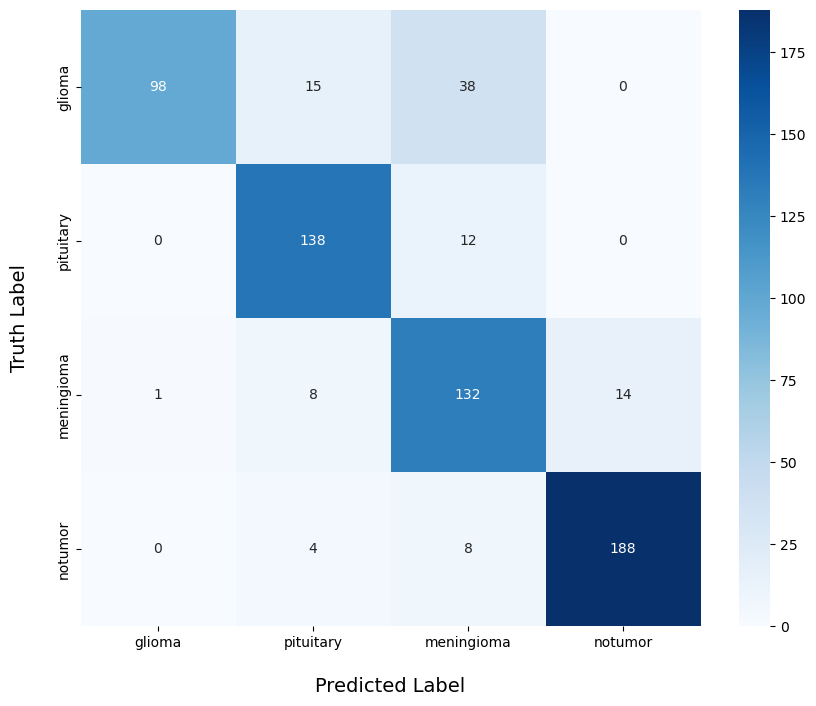

In [38]:
cm = confusion_matrix(gen_labels_test_set, best_model_preds)
labels = set([label[2] for label in test_dataset])
plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
plt.xlabel('Predicted Label', labelpad=20, fontsize=14)
plt.ylabel('Truth Label', labelpad=20, fontsize=14)
plt.show()


In [78]:
y_true = gen_labels_test_set
y_pred = gen_labels_test_set


In [96]:
print(classification_report(gen_labels_test_set, best_model_preds, target_names=labels))


              precision    recall  f1-score   support

      glioma       0.99      0.65      0.78       151
   pituitary       0.84      0.92      0.88       150
  meningioma       0.69      0.85      0.77       155
     notumor       0.93      0.94      0.94       200

    accuracy                           0.85       656
   macro avg       0.86      0.84      0.84       656
weighted avg       0.87      0.85      0.85       656



In [ ]:
class MSCM:
    def __init__(self, shape, beta=0.2, decay_const=0.2, threshold_decay=0.02, h=1.0, f=0.1, max_outer_iters=5):
        self.H, self.W = shape
        self.beta = beta
        self.decay_const = decay_const
        self.threshold_decay = threshold_decay
        self.h = h
        self.f = f  # Scaling factor for threshold computation
        self.max_outer_iters = max_outer_iters  # Maximum iterations for the external loop

        # Initialize neuron states
        self.U = torch.zeros((self.H, self.W))  # Membrane potential
        self.Y = torch.zeros((self.H, self.W))  # Pulse output
        self.E = torch.ones((self.H, self.W))   # Threshold

    def compute_linking_field(self, image):
        kernel = cv2.getGaussianKernel(7, 1)
        kernel = np.outer(kernel, kernel)
        kernel = torch.tensor(kernel, dtype=torch.float32, device=image.device)

        L = F.conv2d(image.unsqueeze(0).unsqueeze(0), kernel.unsqueeze(0).unsqueeze(0), padding=3)
        return L.squeeze()

    def compute_iterations(self, S):
        """
        Compute the number of iterations dynamically based on Otsu's threshold.
        """
        S_numpy = S.cpu().detach().numpy()

        # Ensure the image is converted to uint8
        S_numpy = np.uint8(S_numpy * 255)  

        # Compute Otsu’s threshold
        T_G, _ = cv2.threshold(S_numpy, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

        # Convert T_G to scalar
        T_G = float(T_G)  # Ensure it's a single number, not an array

        # Compute T_S
        T_S = (T_G / (1 - self.f)) + 1

        # Compute number of iterations N
        N = int((np.max(S_numpy) - T_S) / self.threshold_decay) + 1

        return max(N, 10)  # Ensure minimum iterations
    
    def update_neurons(self, S):
        L = self.compute_linking_field(S)
        self.U = self.decay_const * self.U + S * (1 + self.beta * L)

        # Fire neurons when membrane potential exceeds threshold
        new_Y = (self.U > self.E).float()

        # Check if output has stabilized (for the internal loop)
        delta_Y = torch.sum(torch.abs(new_Y - self.Y))

        self.Y = new_Y
        self.E = self.E - self.threshold_decay + self.h * self.Y

        return delta_Y  # Return change in output

    def segment(self, image, iterations=15):
        S = image.clone().detach().to(torch.float32).to('cuda')
        self.U = torch.zeros_like(S, device='cuda')
        self.Y = torch.zeros_like(S, device='cuda')
        self.E = torch.ones_like(S, device='cuda')

        for _ in range(iterations):
            self.update_neurons(S)

        output = self.Y.cpu().detach().numpy()
        output = np.uint8(output * 255)

        # Apply Otsu's thresholding
        _, segmented_image = cv2.threshold(output, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

        # Post-processing: Morphological operations to clean the image
        segmented_image = cv2.morphologyEx(segmented_image, cv2.MORPH_CLOSE, np.ones((5, 5), np.uint8))
        segmented_image = cv2.morphologyEx(segmented_image, cv2.MORPH_OPEN, np.ones((5, 5), np.uint8))

        return segmented_image.astype(np.uint8)





In [ ]:
# Load and preprocess the MRI image
def load_image(image_path):
    image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)  # Load as grayscale
    image = cv2.resize(image, (256, 256))  # Resize for consistency
    image = image / 255.0  # Normalize to [0,1]
    return image

# Test the implementation
if __name__ == "__main__":
    image_path = "../dataset/d2/processed_train/meningioma/Tr-me_0011.jpg"  
    image = load_image(image_path)

    # Convert image to PyTorch tensor and move to GPU
    image_tensor = torch.tensor(image, dtype=torch.float32, device="cuda")

    # Apply MSCM for segmentation
    mscm = MSCM(shape=image_tensor.shape)
    segmented_image = mscm.segment(image_tensor, iterations=15)

    # Display results
    plt.figure(figsize=(10, 5))
    plt.subplot(1, 2, 1)
    plt.imshow(image, cmap="gray")
    plt.title("Original MRI")
    plt.axis("off")

    plt.subplot(1, 2, 2)
    plt.imshow(segmented_image, cmap="gray")
    plt.title("Segmented Tumor Region")
    plt.axis("off")

    plt.show()
